In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tabulate import tabulate
import time
from sklearn.decomposition import PCA
from sklearn.utils import resample
import numpy as np
from matplotlib.colors import ListedColormap


warnings.filterwarnings("ignore", category=UserWarning)

# 1 sekundowe pliki

## 13 cech

In [2]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_13_mfcc_features_with_labels_1sec.csv")  
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_13_mfcc_features_with_labels_1sec.csv")    

X_train = train_data.drop(['Encoded_label'], axis=1) 
y_train = train_data['Encoded_label']

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label'] 

In [3]:
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet', None],
    "C": [0.01, 0.1, 1.0, 10],
    "solver": ['lbfgs', 'saga', 'liblinear'],
    "max_iter": [100, 1000, 10000, 20000],
    "l1_ratio": [0.01, 0.05, 0.1, 0.5]
}

results = []

for penalty in param_grid["penalty"]:
    for C in param_grid["C"]:
        for solver in param_grid["solver"]:
            for max_iter in param_grid["max_iter"]:

                if penalty == 'l1' and solver not in ['saga', 'liblinear']:
                    continue
                if penalty == 'elasticnet' and solver != 'saga':
                    continue
                if penalty is None and solver not in ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if penalty == 'l2' and solver not in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if solver == 'newton-cholesky' and penalty not in [None, 'l2']:
                    continue
                if solver == 'liblinear' and penalty == 'elasticnet':
                    continue

                try:
                    if penalty == 'elasticnet':
                        for l1_ratio in param_grid["l1_ratio"]:
                            model = LogisticRegression(
                                penalty=penalty,
                                multi_class='ovr',
                                C=C,
                                solver=solver,
                                max_iter=max_iter,
                                l1_ratio=l1_ratio,
                                random_state=42
                            )
                            
                            start_time = time.time()
                            model.fit(X_train, y_train)
                            training_time = time.time() - start_time
                            
                            y_pred = model.predict(X_test)
                            results.append({
                                'Penalty': penalty,
                                'C': C,
                                'Solver': solver,
                                'Max Iter': max_iter,
                                'L1 Ratio': l1_ratio,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                                'Recall': recall_score(y_test, y_pred, average='weighted'),
                                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                                'Training Time': training_time
                            })

                    else:
                        model = LogisticRegression(
                            penalty=penalty,
                            C=C,
                            solver=solver,
                            max_iter=max_iter,
                            random_state=42
                        )

                        start_time = time.time()
                        model.fit(X_train, y_train)
                        training_time = time.time() - start_time
                        
                        y_pred = model.predict(X_test)
                        results.append({
                            'Penalty': penalty,
                            'C': C,
                            'Solver': solver,
                            'Max Iter': max_iter,
                            'L1 Ratio': "-",
                            'Accuracy': accuracy_score(y_test, y_pred),
                            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                            'Recall': recall_score(y_test, y_pred, average='weighted'),
                            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                            'Training Time': training_time
                        })

                except Exception as e:
                    print(f"Error with parameters penalty={penalty}, C={C}, solver={solver}, max_iter={max_iter}: {e}")


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time'])

all_models_table = [
    [res['Penalty'], res['C'], res['Solver'], res['Max Iter'], res['L1 Ratio'], res['Accuracy'], res['Precision'], 
     res['Recall'], res['F1 Score'], res['Training Time']]
    for res in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Penalty'], 
     best_models[metric]['C'], 
     best_models[metric]['Solver'], 
     best_models[metric]['Max Iter'], 
     best_models[metric]['L1 Ratio'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Penalty", "C", "Solver", "Max Iter", "L1 Ratio", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
], tablefmt="fancy_grid"))


Best Models for Each Metric:
╒═══════════════╤═══════════╤═════╤══════════╤════════════╤════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════╕
│ Metric        │ Penalty   │   C │ Solver   │   Max Iter │ L1 Ratio   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time │
╞═══════════════╪═══════════╪═════╪══════════╪════════════╪════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════╡
│ Accuracy      │ l2        │ 0.1 │ lbfgs    │      10000 │ -          │   0.836295 │    0.834133 │ 0.836295 │   0.834833 │       18.9385   │
├───────────────┼───────────┼─────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────┤
│ Precision     │ l2        │ 0.1 │ lbfgs    │      10000 │ -          │   0.836295 │    0.834133 │ 0.836295 │   0.834833 │       18.9385   │
├───────────────┼───────────┼─────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼─────────

Regresja logistyczna:
  Dokładność (Accuracy): 0.8363
  Precyzja (Precision): 0.8341
  Recall: 0.8363
  F1 Score: 0.8348
  Czas treningu: 19.6740 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1660
           1       0.73      0.68      0.70      1660
           2       0.81      0.83      0.82      1660
           3       0.95      0.96      0.95      1660

    accuracy                           0.84      6640
   macro avg       0.83      0.84      0.83      6640
weighted avg       0.83      0.84      0.83      6640



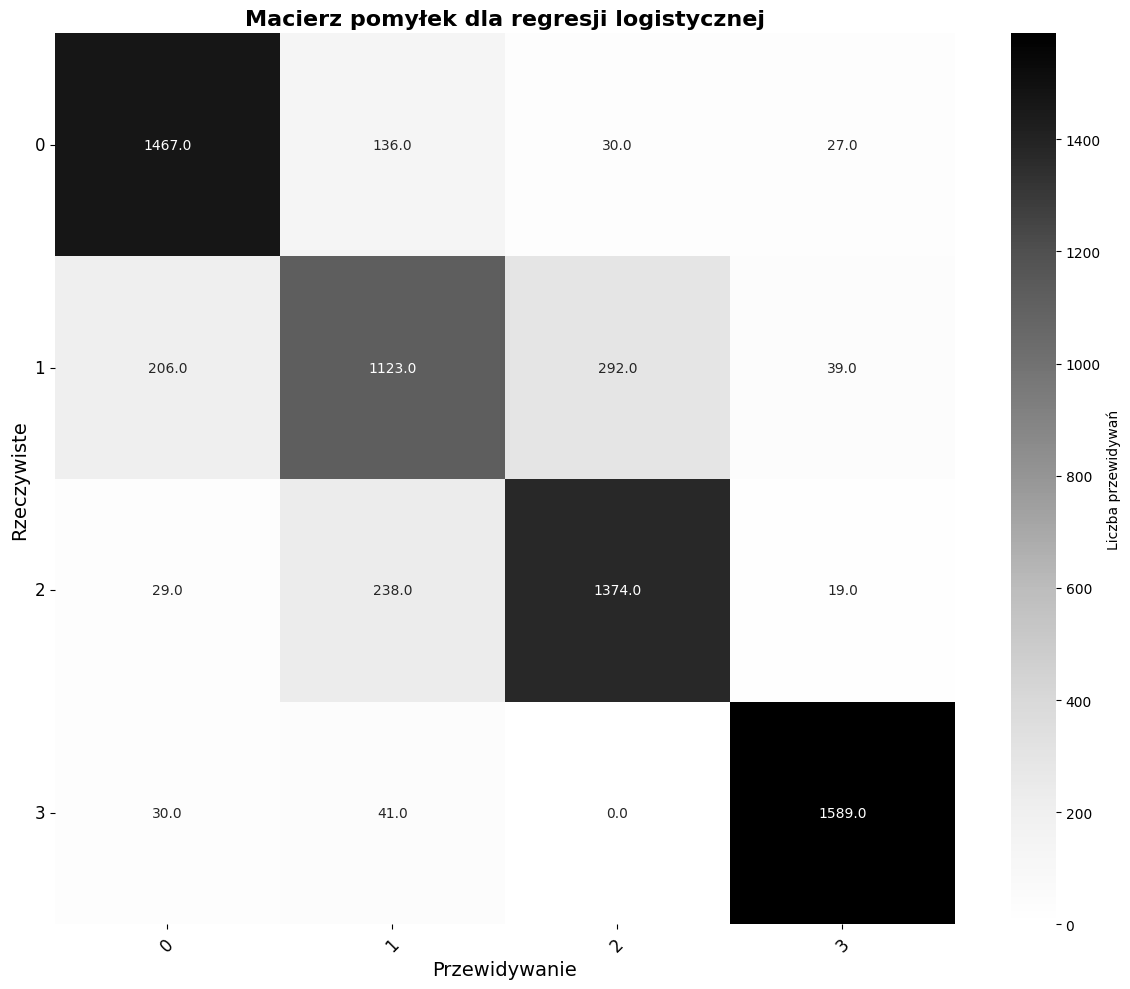

In [4]:
model = LogisticRegression(
    penalty='l2',            
    C=0.1,                   
    solver='lbfgs',         
    max_iter=10000, 
    random_state=42         
)


start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Regresja logistyczna:")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla regresji logistycznej", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


## 30 cech

In [18]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_30_mfcc_features_with_labels_1sec.csv")  
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_30_mfcc_features_with_labels_1sec.csv")    

X_train = train_data.drop(['Encoded_label'], axis=1) 
y_train = train_data['Encoded_label']

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label'] 

In [7]:
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet', None],
    "C": [0.01, 0.1, 1.0, 10],
    "solver": ['lbfgs', 'saga', 'liblinear'],
    "max_iter": [100, 1000, 10000, 20000],
    "l1_ratio": [0.01, 0.05, 0.1, 0.5]
}

results = []

for penalty in param_grid["penalty"]:
    for C in param_grid["C"]:
        for solver in param_grid["solver"]:
            for max_iter in param_grid["max_iter"]:

                if penalty == 'l1' and solver not in ['saga', 'liblinear']:
                    continue
                if penalty == 'elasticnet' and solver != 'saga':
                    continue
                if penalty is None and solver not in ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if penalty == 'l2' and solver not in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if solver == 'newton-cholesky' and penalty not in [None, 'l2']:
                    continue
                if solver == 'liblinear' and penalty == 'elasticnet':
                    continue

                try:
                    if penalty == 'elasticnet':
                        for l1_ratio in param_grid["l1_ratio"]:
                            model = LogisticRegression(
                                penalty=penalty,
                                multi_class='ovr',
                                C=C,
                                solver=solver,
                                max_iter=max_iter,
                                l1_ratio=l1_ratio,
                                random_state=42
                            )
                            
                            start_time = time.time()
                            model.fit(X_train, y_train)
                            training_time = time.time() - start_time
                            
                            y_pred = model.predict(X_test)
                            results.append({
                                'Penalty': penalty,
                                'C': C,
                                'Solver': solver,
                                'Max Iter': max_iter,
                                'L1 Ratio': l1_ratio,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                                'Recall': recall_score(y_test, y_pred, average='weighted'),
                                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                                'Training Time': training_time
                            })

                    else:
                        model = LogisticRegression(
                            penalty=penalty,
                            C=C,
                            multi_class='ovr',
                            solver=solver,
                            max_iter=max_iter,
                            random_state=42
                        )

                        start_time = time.time()
                        model.fit(X_train, y_train)
                        training_time = time.time() - start_time
                        
                        y_pred = model.predict(X_test)
                        results.append({
                            'Penalty': penalty,
                            'C': C,
                            'Solver': solver,
                            'Max Iter': max_iter,
                            'L1 Ratio': "-",
                            'Accuracy': accuracy_score(y_test, y_pred),
                            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                            'Recall': recall_score(y_test, y_pred, average='weighted'),
                            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                            'Training Time': training_time
                        })

                except Exception as e:
                    print(f"Error with parameters penalty={penalty}, C={C}, solver={solver}, max_iter={max_iter}: {e}")


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time'])

all_models_table = [
    [res['Penalty'], res['C'], res['Solver'], res['Max Iter'], res['L1 Ratio'], res['Accuracy'], res['Precision'], 
     res['Recall'], res['F1 Score'], res['Training Time']]
    for res in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Penalty'], 
     best_models[metric]['C'], 
     best_models[metric]['Solver'], 
     best_models[metric]['Max Iter'], 
     best_models[metric]['L1 Ratio'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Penalty", "C", "Solver", "Max Iter", "L1 Ratio", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════╤═════╤══════════╤════════════╤════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════╕
│ Metric        │ Penalty   │   C │ Solver   │   Max Iter │ L1 Ratio   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time │
╞═══════════════╪═══════════╪═════╪══════════╪════════════╪════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════╡
│ Accuracy      │ l1        │  10 │ saga     │       1000 │ -          │   0.863705 │    0.862762 │ 0.863705 │   0.862918 │       10.7647   │
├───────────────┼───────────┼─────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────┤
│ Precision     │ l1        │  10 │ saga     │       1000 │ -          │   0.863705 │    0.862762 │ 0.863705 │   0.862918 │       10.7647   │
├───────────────┼───────────┼─────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼─────────

Regresja logistyczna:
  Dokładność (Accuracy): 0.8560
  Precyzja (Precision): 0.8554
  Recall: 0.8560
  F1 Score: 0.8545
  Czas treningu: 15.9138 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1660
           1       0.80      0.70      0.75      1660
           2       0.78      0.86      0.82      1660
           3       0.95      0.97      0.96      1660

    accuracy                           0.86      6640
   macro avg       0.86      0.86      0.85      6640
weighted avg       0.86      0.86      0.85      6640



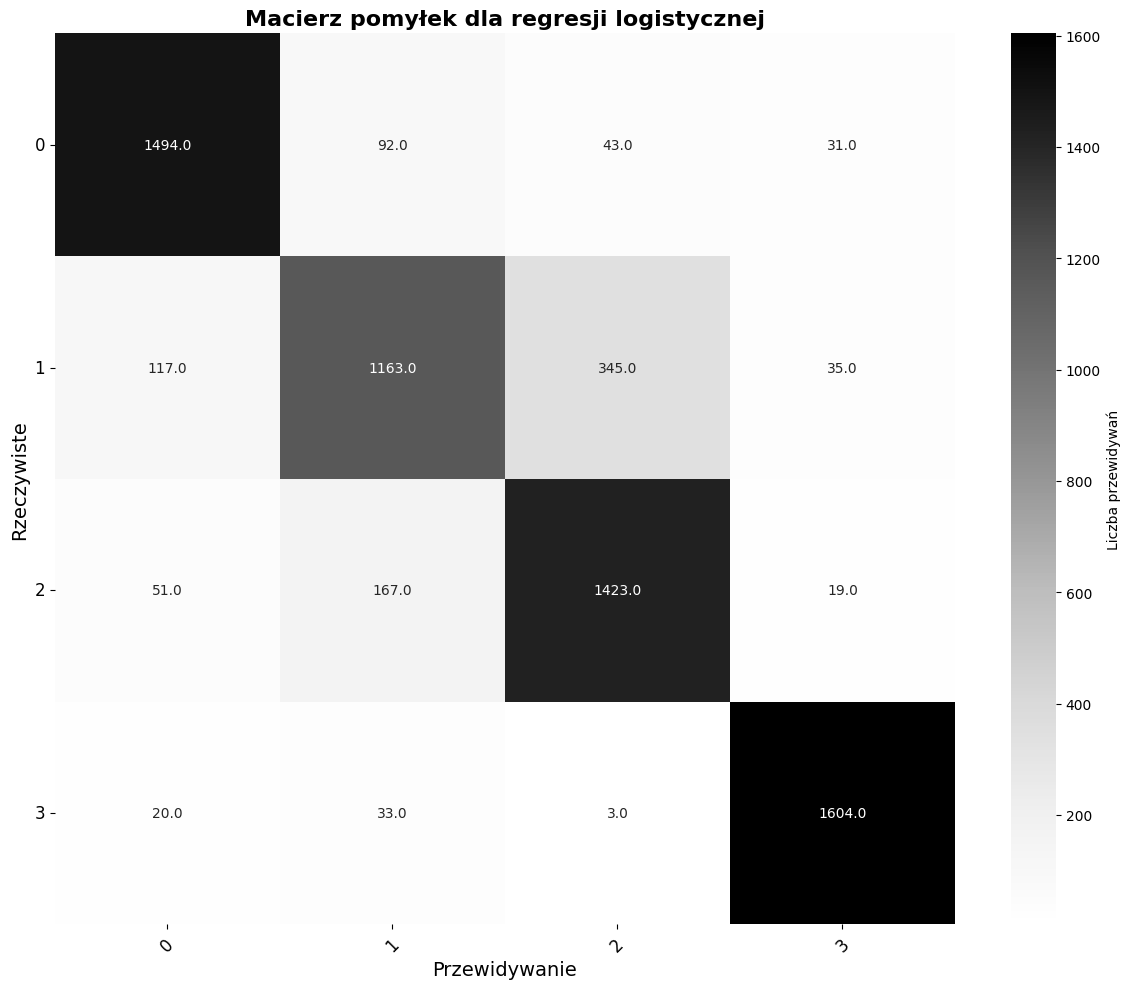

In [16]:
model = LogisticRegression(
    penalty='l1', 
    multi_class='ovr',           
    C=10,                   
    solver='saga',         
    max_iter=1000, 
    random_state=42         
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Regresja logistyczna:")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla regresji logistycznej", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


## 50 cech 

In [21]:
train_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/train_50_mfcc_features_with_labels_1sec.csv")  
test_data = pd.read_csv("Sounds_1_seconds/mfcc_1_sec/test_50_mfcc_features_with_labels_1sec.csv")    

X_train = train_data.drop(['Encoded_label'], axis=1) 
y_train = train_data['Encoded_label']

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label'] 

In [9]:
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet', None],
    "C": [0.01, 0.1, 1.0, 10],
    "solver": ['lbfgs', 'saga', 'liblinear'],
    "max_iter": [100, 1000, 10000, 20000],
    "l1_ratio": [0.01, 0.05, 0.1, 0.5]
}

results = []

for penalty in param_grid["penalty"]:
    for C in param_grid["C"]:
        for solver in param_grid["solver"]:
            for max_iter in param_grid["max_iter"]:

                if penalty == 'l1' and solver not in ['saga', 'liblinear']:
                    continue
                if penalty == 'elasticnet' and solver != 'saga':
                    continue
                if penalty is None and solver not in ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if penalty == 'l2' and solver not in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if solver == 'newton-cholesky' and penalty not in [None, 'l2']:
                    continue
                if solver == 'liblinear' and penalty == 'elasticnet':
                    continue

                try:
                    if penalty == 'elasticnet':
                        for l1_ratio in param_grid["l1_ratio"]:
                            model = LogisticRegression(
                                penalty=penalty,
                                multi_class='ovr',
                                C=C,
                                solver=solver,
                                max_iter=max_iter,
                                l1_ratio=l1_ratio,
                                random_state=42
                            )
                            
                            start_time = time.time()
                            model.fit(X_train, y_train)
                            training_time = time.time() - start_time
                            
                            y_pred = model.predict(X_test)
                            results.append({
                                'Penalty': penalty,
                                'C': C,
                                'Solver': solver,
                                'Max Iter': max_iter,
                                'L1 Ratio': l1_ratio,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                                'Recall': recall_score(y_test, y_pred, average='weighted'),
                                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                                'Training Time': training_time
                            })

                    else:
                        model = LogisticRegression(
                            penalty=penalty,
                            C=C,
                            solver=solver,
                            max_iter=max_iter,
                            random_state=42
                        )

                        start_time = time.time()
                        model.fit(X_train, y_train)
                        training_time = time.time() - start_time
                        
                        y_pred = model.predict(X_test)
                        results.append({
                            'Penalty': penalty,
                            'C': C,
                            'Solver': solver,
                            'Max Iter': max_iter,
                            'L1 Ratio': "-",
                            'Accuracy': accuracy_score(y_test, y_pred),
                            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                            'Recall': recall_score(y_test, y_pred, average='weighted'),
                            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                            'Training Time': training_time
                        })

                except Exception as e:
                    print(f"Error with parameters penalty={penalty}, C={C}, solver={solver}, max_iter={max_iter}: {e}")


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time'])

all_models_table = [
    [res['Penalty'], res['C'], res['Solver'], res['Max Iter'], res['L1 Ratio'], res['Accuracy'], res['Precision'], 
     res['Recall'], res['F1 Score'], res['Training Time']]
    for res in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Penalty'], 
     best_models[metric]['C'], 
     best_models[metric]['Solver'], 
     best_models[metric]['Max Iter'], 
     best_models[metric]['L1 Ratio'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Penalty", "C", "Solver", "Max Iter", "L1 Ratio", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════╤═══════╤══════════╤════════════╤════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════╕
│ Metric        │ Penalty   │     C │ Solver   │   Max Iter │ L1 Ratio   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time │
╞═══════════════╪═══════════╪═══════╪══════════╪════════════╪════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════╡
│ Accuracy      │ l2        │  0.01 │ lbfgs    │      20000 │ -          │   0.874247 │    0.873108 │ 0.874247 │   0.872892 │       70.6147   │
├───────────────┼───────────┼───────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────┤
│ Precision     │ l2        │ 10    │ lbfgs    │      10000 │ -          │   0.874247 │    0.873152 │ 0.874247 │   0.87294  │       56.6773   │
├───────────────┼───────────┼───────┼──────────┼────────────┼────────────┼────────────┼─────────────┼──────

Regresja logistyczna:
  Dokładność (Accuracy): 0.8654
  Precyzja (Precision): 0.8646
  Recall: 0.8654
  F1 Score: 0.8634
  Czas treningu: 7.3957 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      1660
           1       0.81      0.70      0.75      1660
           2       0.81      0.87      0.84      1660
           3       0.97      0.97      0.97      1660

    accuracy                           0.87      6640
   macro avg       0.86      0.87      0.86      6640
weighted avg       0.86      0.87      0.86      6640



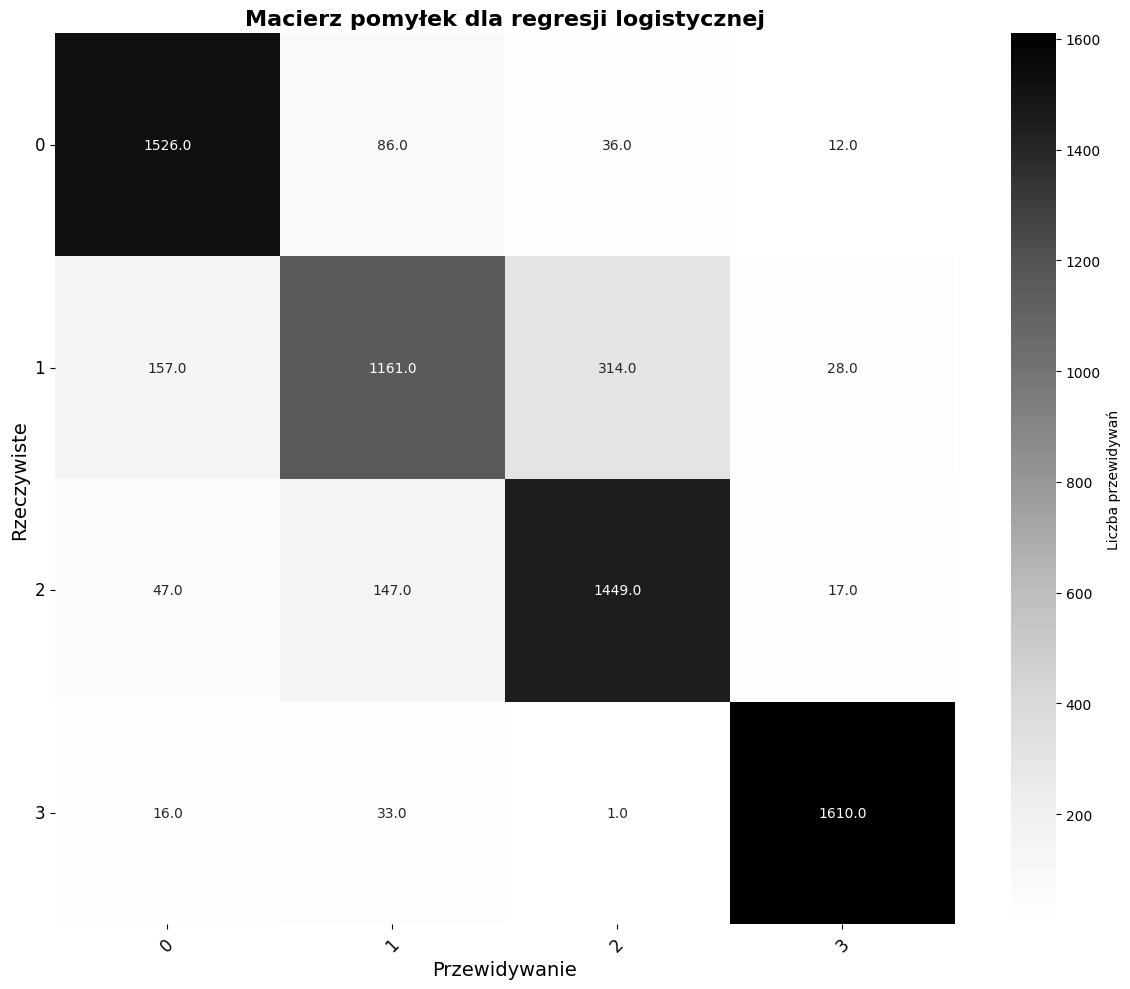

In [23]:
model = LogisticRegression(
    penalty='l2', 
    multi_class='ovr',           
    C=0.01,                   
    solver='lbfgs',         
    max_iter=20000, 
    random_state=42         
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Regresja logistyczna:")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla regresji logistycznej", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


# 3 sekundowe pliki

In [32]:
train_data = pd.read_csv("Sounds_3_seconds/mfcc_3_sec/train_13_mfcc_features_with_labels_3sec.csv")  
test_data = pd.read_csv("Sounds_3_seconds/mfcc_3_sec/test_13_mfcc_features_with_labels_3sec.csv")    

X_train = train_data.drop(['Encoded_label'], axis=1) 
y_train = train_data['Encoded_label']

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label'] 

In [11]:
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet', None],
    "C": [0.01, 0.1, 1.0, 10],
    "solver": ['lbfgs', 'saga', 'liblinear'],
    "max_iter": [100, 1000, 10000, 20000],
    "l1_ratio": [0.01, 0.05, 0.1, 0.5]
}

results = []

for penalty in param_grid["penalty"]:
    for C in param_grid["C"]:
        for solver in param_grid["solver"]:
            for max_iter in param_grid["max_iter"]:

                if penalty == 'l1' and solver not in ['saga', 'liblinear']:
                    continue
                if penalty == 'elasticnet' and solver != 'saga':
                    continue
                if penalty is None and solver not in ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if penalty == 'l2' and solver not in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if solver == 'newton-cholesky' and penalty not in [None, 'l2']:
                    continue
                if solver == 'liblinear' and penalty == 'elasticnet':
                    continue

                try:
                    if penalty == 'elasticnet':
                        for l1_ratio in param_grid["l1_ratio"]:
                            model = LogisticRegression(
                                penalty=penalty,
                                multi_class='ovr',
                                C=C,
                                solver=solver,
                                max_iter=max_iter,
                                l1_ratio=l1_ratio,
                                random_state=42
                            )
                            
                            start_time = time.time()
                            model.fit(X_train, y_train)
                            training_time = time.time() - start_time
                            
                            y_pred = model.predict(X_test)
                            results.append({
                                'Penalty': penalty,
                                'C': C,
                                'Solver': solver,
                                'Max Iter': max_iter,
                                'L1 Ratio': l1_ratio,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                                'Recall': recall_score(y_test, y_pred, average='weighted'),
                                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                                'Training Time': training_time
                            })

                    else:
                        model = LogisticRegression(
                            penalty=penalty,
                            C=C,
                            solver=solver,
                            max_iter=max_iter,
                            random_state=42
                        )

                        start_time = time.time()
                        model.fit(X_train, y_train)
                        training_time = time.time() - start_time
                        
                        y_pred = model.predict(X_test)
                        results.append({
                            'Penalty': penalty,
                            'C': C,
                            'Solver': solver,
                            'Max Iter': max_iter,
                            'L1 Ratio': "-",
                            'Accuracy': accuracy_score(y_test, y_pred),
                            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                            'Recall': recall_score(y_test, y_pred, average='weighted'),
                            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                            'Training Time': training_time
                        })

                except Exception as e:
                    print(f"Error with parameters penalty={penalty}, C={C}, solver={solver}, max_iter={max_iter}: {e}")


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time'])

all_models_table = [
    [res['Penalty'], res['C'], res['Solver'], res['Max Iter'], res['L1 Ratio'], res['Accuracy'], res['Precision'], 
     res['Recall'], res['F1 Score'], res['Training Time']]
    for res in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Penalty'], 
     best_models[metric]['C'], 
     best_models[metric]['Solver'], 
     best_models[metric]['Max Iter'], 
     best_models[metric]['L1 Ratio'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Penalty", "C", "Solver", "Max Iter", "L1 Ratio", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════╤══════╤═══════════╤════════════╤════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════╕
│ Metric        │ Penalty   │    C │ Solver    │   Max Iter │ L1 Ratio   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time │
╞═══════════════╪═══════════╪══════╪═══════════╪════════════╪════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════╡
│ Accuracy      │ l2        │ 0.01 │ lbfgs     │       1000 │ -          │   0.846552 │    0.84433  │ 0.846552 │   0.844854 │        1.49972  │
├───────────────┼───────────┼──────┼───────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────┤
│ Precision     │ l2        │ 1    │ lbfgs     │       1000 │ -          │   0.846552 │    0.844331 │ 0.846552 │   0.844921 │        1.56683  │
├───────────────┼───────────┼──────┼───────────┼────────────┼────────────┼────────────┼─────────────┼──────

Regresja logistyczna:
  Dokładność (Accuracy): 0.8366
  Precyzja (Precision): 0.8339
  Recall: 0.8366
  F1 Score: 0.8333
  Czas treningu: 1.2193 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       580
           1       0.75      0.63      0.68       580
           2       0.82      0.86      0.84       580
           3       0.96      0.97      0.96       580

    accuracy                           0.84      2320
   macro avg       0.83      0.84      0.83      2320
weighted avg       0.83      0.84      0.83      2320



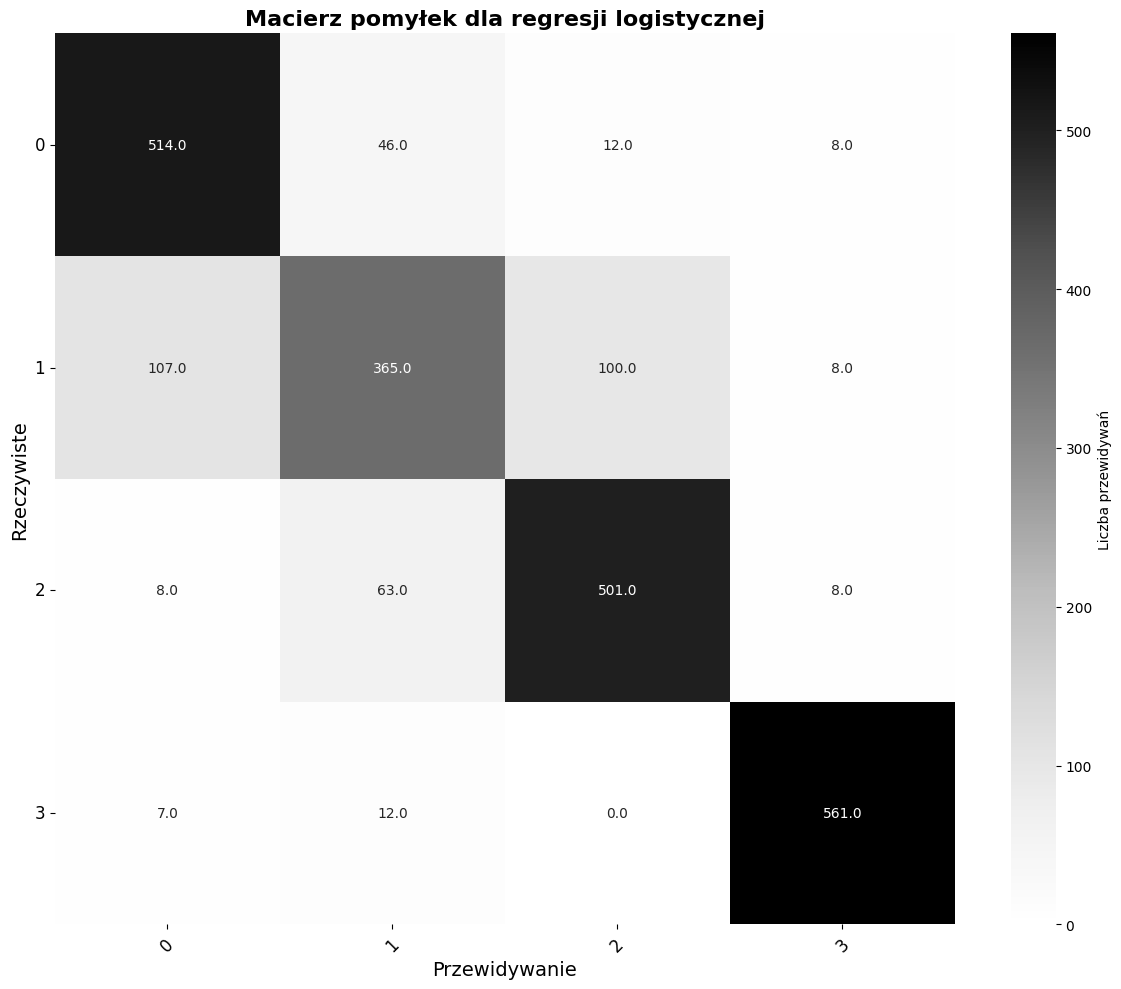

In [33]:
model = LogisticRegression(
    penalty='l2', 
    multi_class='ovr',           
    C=0.01,                   
    solver='lbfgs',         
    max_iter=1000, 
    random_state=42         
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Regresja logistyczna:")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla regresji logistycznej", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# 5 sekundowe pliki

In [27]:
train_data = pd.read_csv("Sounds_5_seconds/mfcc_5_sec/train_13_mfcc_features_with_labels_5sec.csv")  
test_data = pd.read_csv("Sounds_5_seconds/mfcc_5_sec/test_13_mfcc_features_with_labels_5sec.csv")    

X_train = train_data.drop(['Encoded_label'], axis=1) 
y_train = train_data['Encoded_label']

X_test = test_data.drop(['Encoded_label'], axis=1)  
y_test = test_data['Encoded_label'] 

In [13]:
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet', None],
    "C": [0.01, 0.1, 1.0, 10],
    "solver": ['lbfgs', 'saga', 'liblinear'],
    "max_iter": [100, 1000, 10000, 20000],
    "l1_ratio": [0.01, 0.05, 0.1, 0.5]
}

results = []

for penalty in param_grid["penalty"]:
    for C in param_grid["C"]:
        for solver in param_grid["solver"]:
            for max_iter in param_grid["max_iter"]:

                if penalty == 'l1' and solver not in ['saga', 'liblinear']:
                    continue
                if penalty == 'elasticnet' and solver != 'saga':
                    continue
                if penalty is None and solver not in ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if penalty == 'l2' and solver not in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
                    continue
                if solver == 'newton-cholesky' and penalty not in [None, 'l2']:
                    continue
                if solver == 'liblinear' and penalty == 'elasticnet':
                    continue

                try:
                    if penalty == 'elasticnet':
                        for l1_ratio in param_grid["l1_ratio"]:
                            model = LogisticRegression(
                                penalty=penalty,
                                multi_class='ovr',
                                C=C,
                                solver=solver,
                                max_iter=max_iter,
                                l1_ratio=l1_ratio,
                                random_state=42
                            )
                            
                            start_time = time.time()
                            model.fit(X_train, y_train)
                            training_time = time.time() - start_time
                            
                            y_pred = model.predict(X_test)
                            results.append({
                                'Penalty': penalty,
                                'C': C,
                                'Solver': solver,
                                'Max Iter': max_iter,
                                'L1 Ratio': l1_ratio,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                                'Recall': recall_score(y_test, y_pred, average='weighted'),
                                'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                                'Training Time': training_time
                            })

                    else:
                        model = LogisticRegression(
                            penalty=penalty,
                            C=C,
                            solver=solver,
                            max_iter=max_iter,
                            random_state=42
                        )

                        start_time = time.time()
                        model.fit(X_train, y_train)
                        training_time = time.time() - start_time
                        
                        y_pred = model.predict(X_test)
                        results.append({
                            'Penalty': penalty,
                            'C': C,
                            'Solver': solver,
                            'Max Iter': max_iter,
                            'L1 Ratio': "-",
                            'Accuracy': accuracy_score(y_test, y_pred),
                            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                            'Recall': recall_score(y_test, y_pred, average='weighted'),
                            'F1 Score': f1_score(y_test, y_pred, average='weighted'),
                            'Training Time': training_time
                        })

                except Exception as e:
                    print(f"Error with parameters penalty={penalty}, C={C}, solver={solver}, max_iter={max_iter}: {e}")


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
best_models = {metric: max(results, key=lambda x: x[metric]) for metric in metrics}
best_models['Training Time'] = min(results, key=lambda x: x['Training Time'])

all_models_table = [
    [res['Penalty'], res['C'], res['Solver'], res['Max Iter'], res['L1 Ratio'], res['Accuracy'], res['Precision'], 
     res['Recall'], res['F1 Score'], res['Training Time']]
    for res in results
]

best_models_table = [
    [metric, 
     best_models[metric]['Penalty'], 
     best_models[metric]['C'], 
     best_models[metric]['Solver'], 
     best_models[metric]['Max Iter'], 
     best_models[metric]['L1 Ratio'], 
     best_models[metric]['Accuracy'], 
     best_models[metric]['Precision'], 
     best_models[metric]['Recall'], 
     best_models[metric]['F1 Score'], 
     best_models[metric]['Training Time']]
    for metric in metrics + ['Training Time']
]

print("Best Models for Each Metric:")
print(tabulate(best_models_table, headers=[
    "Metric", "Penalty", "C", "Solver", "Max Iter", "L1 Ratio", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
], tablefmt="fancy_grid"))

Best Models for Each Metric:
╒═══════════════╤═══════════╤══════╤═══════════╤════════════╤════════════╤════════════╤═════════════╤══════════╤════════════╤═════════════════╕
│ Metric        │ Penalty   │    C │ Solver    │   Max Iter │ L1 Ratio   │   Accuracy │   Precision │   Recall │   F1 Score │   Training Time │
╞═══════════════╪═══════════╪══════╪═══════════╪════════════╪════════════╪════════════╪═════════════╪══════════╪════════════╪═════════════════╡
│ Accuracy      │ l1        │ 1    │ saga      │       1000 │ -          │   0.867188 │    0.866503 │ 0.867188 │    0.86592 │        2.68255  │
├───────────────┼───────────┼──────┼───────────┼────────────┼────────────┼────────────┼─────────────┼──────────┼────────────┼─────────────────┤
│ Precision     │ l1        │ 1    │ saga      │       1000 │ -          │   0.867188 │    0.866503 │ 0.867188 │    0.86592 │        2.68255  │
├───────────────┼───────────┼──────┼───────────┼────────────┼────────────┼────────────┼─────────────┼──────

Regresja logistyczna:
  Dokładność (Accuracy): 0.8430
  Precyzja (Precision): 0.8436
  Recall: 0.8430
  F1 Score: 0.8384
  Czas treningu: 3.0209 sekund

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       320
           1       0.81      0.61      0.70       320
           2       0.83      0.89      0.86       320
           3       0.96      0.97      0.97       320

    accuracy                           0.84      1280
   macro avg       0.84      0.84      0.84      1280
weighted avg       0.84      0.84      0.84      1280



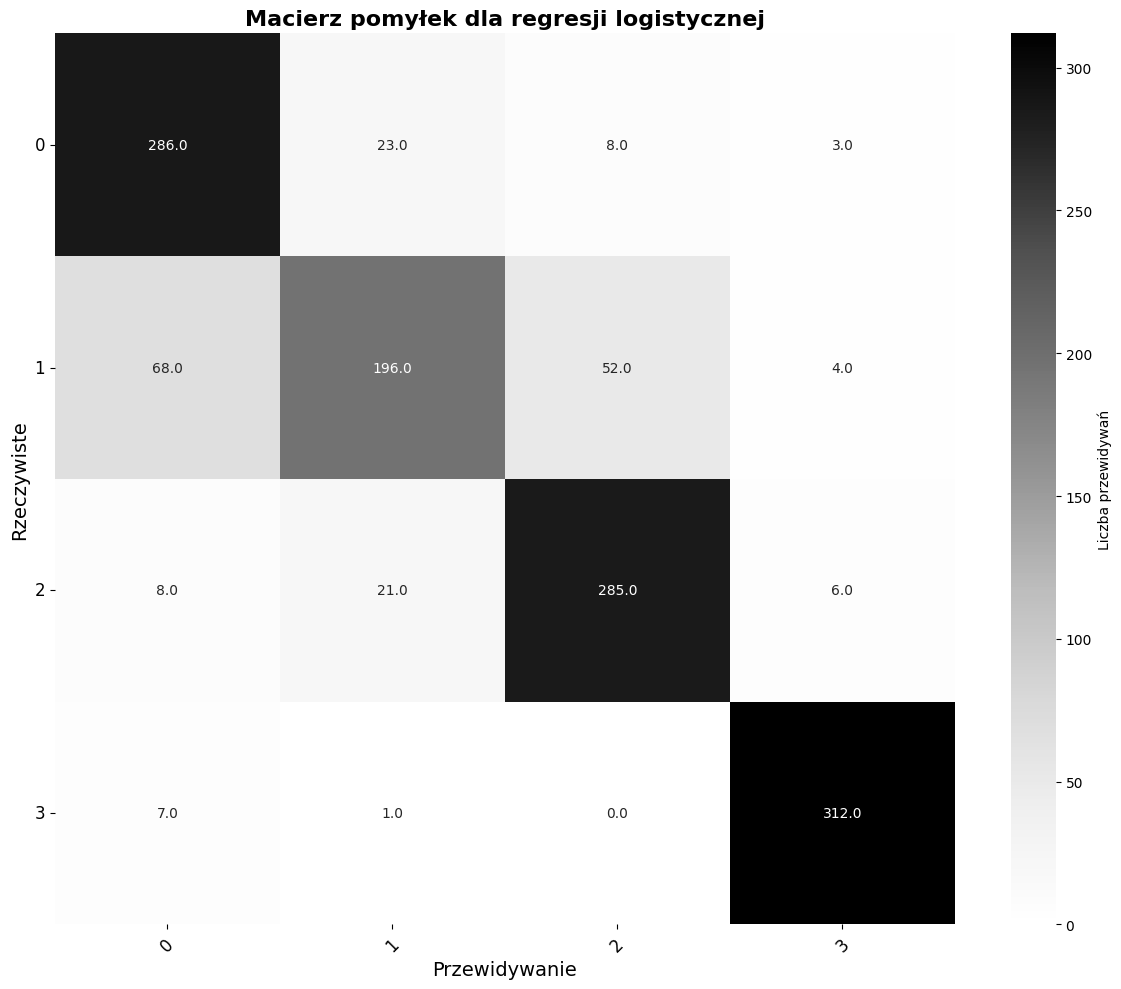

In [29]:
model = LogisticRegression(
    penalty='l1', 
    multi_class='ovr',           
    C=1.0,                   
    solver='saga',         
    max_iter=1000, 
    random_state=42         
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time


unique_labels = y_test.unique()
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Regresja logistyczna:")
print(f"  Dokładność (Accuracy): {accuracy:.4f}")
print(f"  Precyzja (Precision): {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Czas treningu: {training_time:.4f} sekund")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(label) for label in sorted(unique_labels)]))


sorted_labels = np.sort(unique_labels)
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="Greys", 
            xticklabels=sorted_labels, yticklabels=sorted_labels, cbar_kws={'label': 'Liczba przewidywań'})

plt.xlabel("Przewidywanie", fontsize=14)
plt.ylabel("Rzeczywiste", fontsize=14)
plt.title("Macierz pomyłek dla regresji logistycznej", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


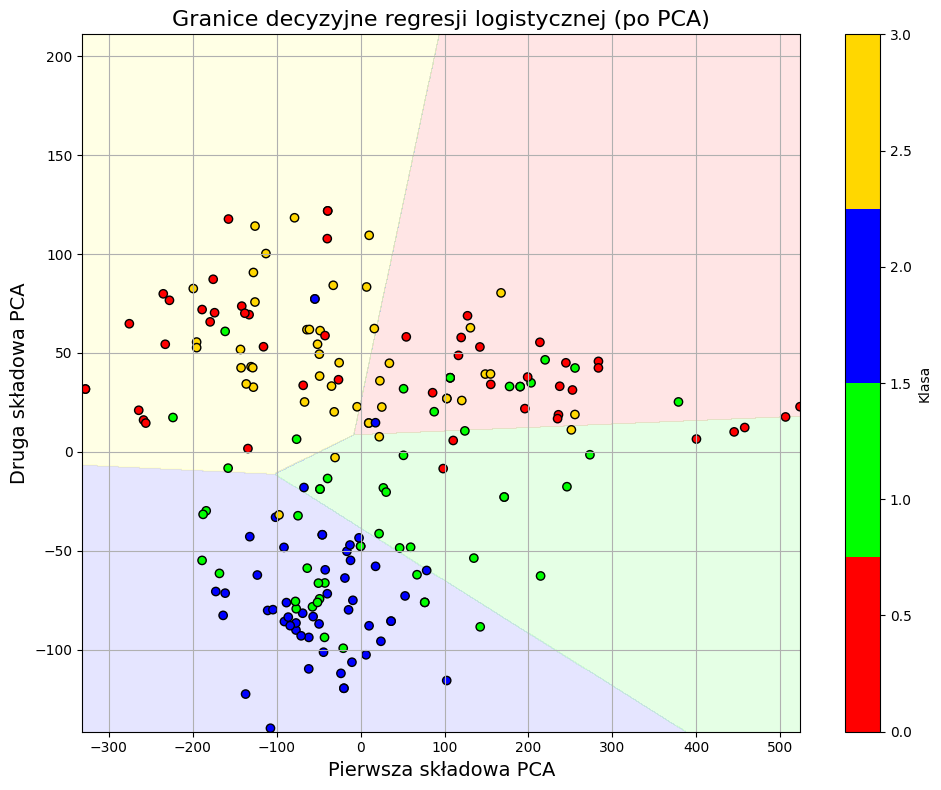

In [30]:
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

model = LogisticRegression(
    penalty='l2', 
    multi_class='ovr',           
    C=0.01,                   
    solver='lbfgs',         
    max_iter=20000, 
    random_state=42         
)

model.fit(X_train_2D, y_train)

x_min, x_max = X_test_2D[:, 0].min() - 0.5, X_test_2D[:, 0].max() + 0.5
y_min, y_max = X_test_2D[:, 1].min() - 0.5, X_test_2D[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),  
                     np.arange(y_min, y_max, 0.5))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

X_test_sampled, y_test_sampled = resample(X_test_2D, y_test, n_samples=200, random_state=42)

colors = ['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA']
scatter_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFD700']

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(colors))
plt.scatter(X_test_sampled[:, 0], X_test_sampled[:, 1], c=y_test_sampled, edgecolors='k', cmap=ListedColormap(scatter_colors))
plt.title('Granice decyzyjne regresji logistycznej (po PCA)', fontsize=16)
plt.xlabel('Pierwsza składowa PCA', fontsize=14)
plt.ylabel('Druga składowa PCA', fontsize=14)
plt.colorbar(label='Klasa')
plt.grid(True)
plt.tight_layout()
plt.show()